# Visualizzazione Avanzata Risultati e Anatomia Lesionale 3D

Questo notebook permette di caricare un output salvato della pipeline (da `results/`) e visualizzare lo spazio di embedding in 2D e 3D.

Inoltre, consente di selezionare un soggetto e visualizzare la sua lesione cerebrale in un visualizzatore 3D interattivo direttamente nel notebook.

In [1]:
import sys
import os
import json
import itertools
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import ConnectionPatch
import matplotlib.patheffects as pe
import seaborn as sns
import plotly.graph_objects as go
from nilearn import plotting
from IPython.display import display, Image

# Ripristina il backend interattivo per i plot inline nel notebook - va fatto qui, prima di
# qualunque figura, perche' nilearn (importato sopra) spesso forza un backend non interattivo
# (es. Agg) - stesso fix di notebooks/pipeline_building/dim_reduction.ipynb.
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")

# Risale da cwd fino a trovare la root del repo (contiene environment.yml) - non assume un
# numero fisso di livelli: cwd dipende da come il kernel Jupyter e' stato lanciato (IDE/editor),
# non dalla posizione del notebook sul filesystem.
root_path = Path.cwd()
while not (root_path / "environment.yml").exists():
    if root_path.parent == root_path:
        raise RuntimeError(
            "could not locate project root (no environment.yml found in any parent directory of "
            f"{Path.cwd()}) - run this notebook with a working directory somewhere inside the NEMESIS repo"
        )
    root_path = root_path.parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

from src.utils.artifacts import load_matrix
import nibabel as nib
from src.features.lesion import load_reference_image
from src.features.subject_discovery import discover_files_by_subject
from src.analysis.embedding_coloring import COLOR_MODES
from src.analysis.plotting import (
    _CATEGORICAL_PALETTE, _NOISE_COLOR, _MARKER_SIZE, _AXIS_PADDING_FRACTION,
    plot_embedding_2d, plot_embedding_categorical, plot_embedding_continuous,
    compose_embedding_plot_title,
)

# Stessa mappa di scripts/replot_dim_reduction.py::_PERSISTED_COLUMN_BY_MODE - leggiamo le colonne
# gia' persistite in metadata.csv a tempo di produzione (dataset/lesion_side/lesion_volume_voxels/
# nihss), mai ricalcolate qui: in questo notebook X e' l'embedding, non la matrice voxel grezza
# che COLOR_MODES[...].compute si aspetterebbe.
_PERSISTED_COLUMN_BY_MODE = {
    "dataset": "dataset",
    "side": "lesion_side",
    "volume": "lesion_volume_voxels",
    "nihss": "nihss",
}

# Larghezza di visualizzazione (px) per i plot statici mostrati via Image - non tocca la
# dimensione/dpi reale con cui plot_embedding_2d/_categorical/_continuous salvano il PNG (quelle
# sono le funzioni vere di produzione, non le tocchiamo), solo quanto grande appare nel notebook.
_STATIC_DISPLAY_WIDTH = 620


def _palette_for(categories, missing_label="unknown"):
    palette, colors = {}, itertools.cycle(_CATEGORICAL_PALETTE)
    for cat in categories:
        palette[cat] = _NOISE_COLOR if cat == missing_label else next(colors)
    return palette


def _panel_title(mode_name):
    return "Neutro" if mode_name == "neutro" else COLOR_MODES[mode_name].label.capitalize()


def _color_label(mode_name):
    """None (colorazione neutra, niente terzo segmento nel titolo) oppure l'etichetta REALE
    del color mode (es. "lesion side", "NIHSS (severity)") - stessa stringa che
    scripts/replot_dim_reduction.py passa a compose_embedding_plot_title in produzione, cosi'
    il titolo del notebook e' identico a quello che la pipeline avrebbe scritto su disco."""
    return None if mode_name == "neutro" else COLOR_MODES[mode_name].label


print("Librerie importate correttamente.")


Librerie importate correttamente.


## 1. Caricamento del Risultato della Pipeline

Scegliere la cartella dei risultati da ispezionare (dim_reduction ). Il notebook caricherà l'embedding e i metadati associati.

In [2]:
# Percorso dei risultati (modificare a piacimento)
results_dir = root_path / "results/lesion/dim_reduction/production/umap/11-08_s1.1-vol_m_euclidean_nc2"

if not results_dir.exists():
    # Fallback su un percorso generico per prevenire errori al primo avvio
    parent_results = root_path / "results/lesion/dim_reduction"
    subdirs = sorted([d for d in parent_results.glob("**/*") if d.is_dir() and (d / "manifest.json").exists()])
    if subdirs:
        results_dir = subdirs[-1]
        print(f"Cartella di fallback trovata: {results_dir}")
    else:
        parent_results = root_path / "results/lesion/dim_reduction_clustering"
        subdirs = sorted([d for d in parent_results.glob("**/*") if d.is_dir() and (d / "manifest.json").exists()])
        if subdirs:
            results_dir = subdirs[-1]
            print(f"Cartella di fallback trovata: {results_dir}")

try:
    embedding, metadata, extra_arrays = load_matrix(results_dir)
    # Stessa convenzione di scripts/replot_dim_reduction.py::_replot_embedding - il nome della
    # cartella immediatamente sopra results_dir e' il metodo di riduzione (umap/tsne/...), letto
    # dal path stesso e mai hardcoded, cosi' titoli/etichette restano metodo-agnostici.
    reduction_method = results_dir.parent.name
    # compose_embedding_plot_title (src/analysis/plotting.py) si aspetta un path che inizi con
    # "results/..." (cosi' come lo costruiscono i pipeline script, sempre relativo) - results_dir
    # qui e' assoluto (root_path e' assoluto, vedi cella import), quindi gli passiamo la versione
    # relativa alla root del repo, mai results_dir direttamente (altrimenti il primo segmento del
    # path e' "/" invece di "results" e il titolo risulta "/s - Umap" invece di "Lesions - Umap").
    results_dir_rel = results_dir.relative_to(root_path)
    print(f"Risultati caricati con successo da: {results_dir}")
    print(f"Metodo di riduzione: {reduction_method}")
    print(f"Shape dell'embedding: {embedding.shape}")
    print(f"Colonne metadati: {list(metadata.columns)}")
except Exception as e:
    print(f"Errore: impossibile caricare i risultati da {results_dir}. Assicurarsi che la pipeline abbia prodotto dei risultati. Dettaglio: {e}")


Risultati caricati con successo da: /Users/emmatosato/Local Projects/Local PhD Projects/NEMESIS_fs/results/lesion/dim_reduction/production/umap/11-08_s1.1_m_euclidean_nc2
Metodo di riduzione: umap
Shape dell'embedding: (1150, 2)
Colonne metadati: ['subject_id', 'dataset', 'lesion_volume_voxels', 'lesion_side', 'nihss']


## 2. Visualizzazione statica (matplotlib) — 2D

### 2.1 Plot unico, colorazione a scelta

In [3]:
# "neutro" (nessuna colorazione, stile embedding_plot_unico.png) oppure uno dei nomi di
# COLOR_MODES: "dataset", "side", "volume", "nihss" (stile embedding_plot_<nome>.png)
single_color_by = "neutro"


In [4]:
def show_embedding_single(X_2d, mode_name, metadata, title, xlabel, ylabel, display_width=_STATIC_DISPLAY_WIDTH):
    """Plot singolo con le funzioni REALI di src/analysis/plotting.py (le stesse che
    hanno prodotto embedding_plot_*.png in produzione) - mai una reimplementazione a
    mano, cosi' lo stile (palette/font/legenda/colorbar) e' garantito identico.

    display_width scala solo la resa nel notebook (attributo HTML width di Image), non il
    PNG salvato su disco - le funzioni di produzione restano intoccate."""
    with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as tmp:
        output_path = Path(tmp.name)

    if mode_name == "neutro":
        plot_embedding_2d(X_2d, output_path, xlabel, ylabel, title)
    else:
        mode = COLOR_MODES[mode_name]
        values = metadata[_PERSISTED_COLUMN_BY_MODE[mode_name]].to_numpy()
        if mode.kind == "categorical":
            plot_embedding_categorical(X_2d, values, output_path, xlabel, ylabel, title, legend_title=mode.label)
        else:
            plot_embedding_continuous(X_2d, values, output_path, xlabel, ylabel, title, colorbar_label=mode.label, log_scale=mode.log_scale)

    display(Image(filename=str(output_path), width=display_width))


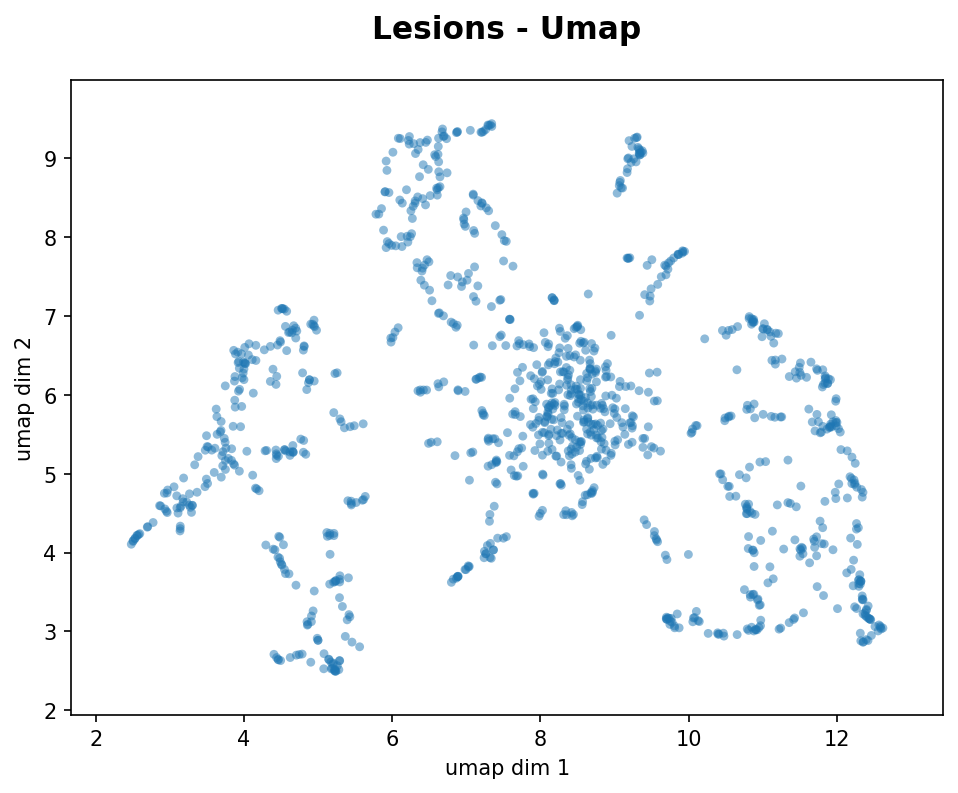

In [5]:
if 'embedding' in locals() and embedding.shape[1] >= 2:
    show_embedding_single(
        embedding[:, :2], single_color_by, metadata,
        compose_embedding_plot_title(results_dir_rel, reduction_method, _color_label(single_color_by)),
        f"{reduction_method} dim 1", f"{reduction_method} dim 2",
    )
else:
    print("Dati non caricati o embedding con meno di 2 dimensioni.")


### 2.2 Griglia di subplot — un pannello per colorazione scelta

In [6]:
# Un pannello per ogni elemento, nell'ordine dato qui - "neutro" o un nome di COLOR_MODES
# ("dataset", "side", "volume", "nihss"). Il numero di pannelli si adatta da solo a quanti
# elementi metti in questa lista.
color_by = ["dataset", "side", "volume", "nihss"]


In [7]:
def plot_embedding_panel(ax, X_2d, mode_name, metadata, title, xlabel, ylabel):
    x_min, x_max = X_2d[:, 0].min(), X_2d[:, 0].max()
    y_min, y_max = X_2d[:, 1].min(), X_2d[:, 1].max()
    x_pad = (x_max - x_min) * _AXIS_PADDING_FRACTION
    y_pad = (y_max - y_min) * _AXIS_PADDING_FRACTION
    ax.set_xlim(x_min - x_pad, x_max + x_pad)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)

    if mode_name == "neutro":
        ax.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.5, s=_MARKER_SIZE, edgecolor="none")
    else:
        mode = COLOR_MODES[mode_name]
        values = metadata[_PERSISTED_COLUMN_BY_MODE[mode_name]].to_numpy()

        if mode.kind == "categorical":
            unique_categories = sorted(pd.unique(values).tolist())
            sns.scatterplot(
                x=X_2d[:, 0], y=X_2d[:, 1], hue=values, hue_order=unique_categories,
                palette=_palette_for(unique_categories), s=_MARKER_SIZE, edgecolor="none",
                legend="full", ax=ax,
            )
            # Dentro gli assi, non bbox_to_anchor fuori - con piu' pannelli per riga una legenda
            # esterna si sovrappone al pannello successivo (constrained_layout non la conta).
            ax.legend(title=mode.label, loc="best", fontsize=7, title_fontsize=8, framealpha=0.85, markerscale=0.8)
        else:
            values = np.asarray(values, dtype=float)
            is_missing = np.isnan(values)
            norm = None
            if mode.log_scale and (~is_missing).any():
                norm = mcolors.LogNorm(vmin=values[~is_missing].min(), vmax=values[~is_missing].max())
            if is_missing.any():
                ax.scatter(X_2d[is_missing, 0], X_2d[is_missing, 1], c=_NOISE_COLOR, s=_MARKER_SIZE, edgecolor="none", label="missing")
            scatter = ax.scatter(X_2d[~is_missing, 0], X_2d[~is_missing, 1], c=values[~is_missing], cmap="viridis", norm=norm, s=_MARKER_SIZE, edgecolor="none")
            ax.get_figure().colorbar(scatter, ax=ax, label=mode.label, fraction=0.046, pad=0.04)
            if is_missing.any():
                ax.legend(loc="best", framealpha=0.85, fontsize=7)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=11, fontweight="bold")


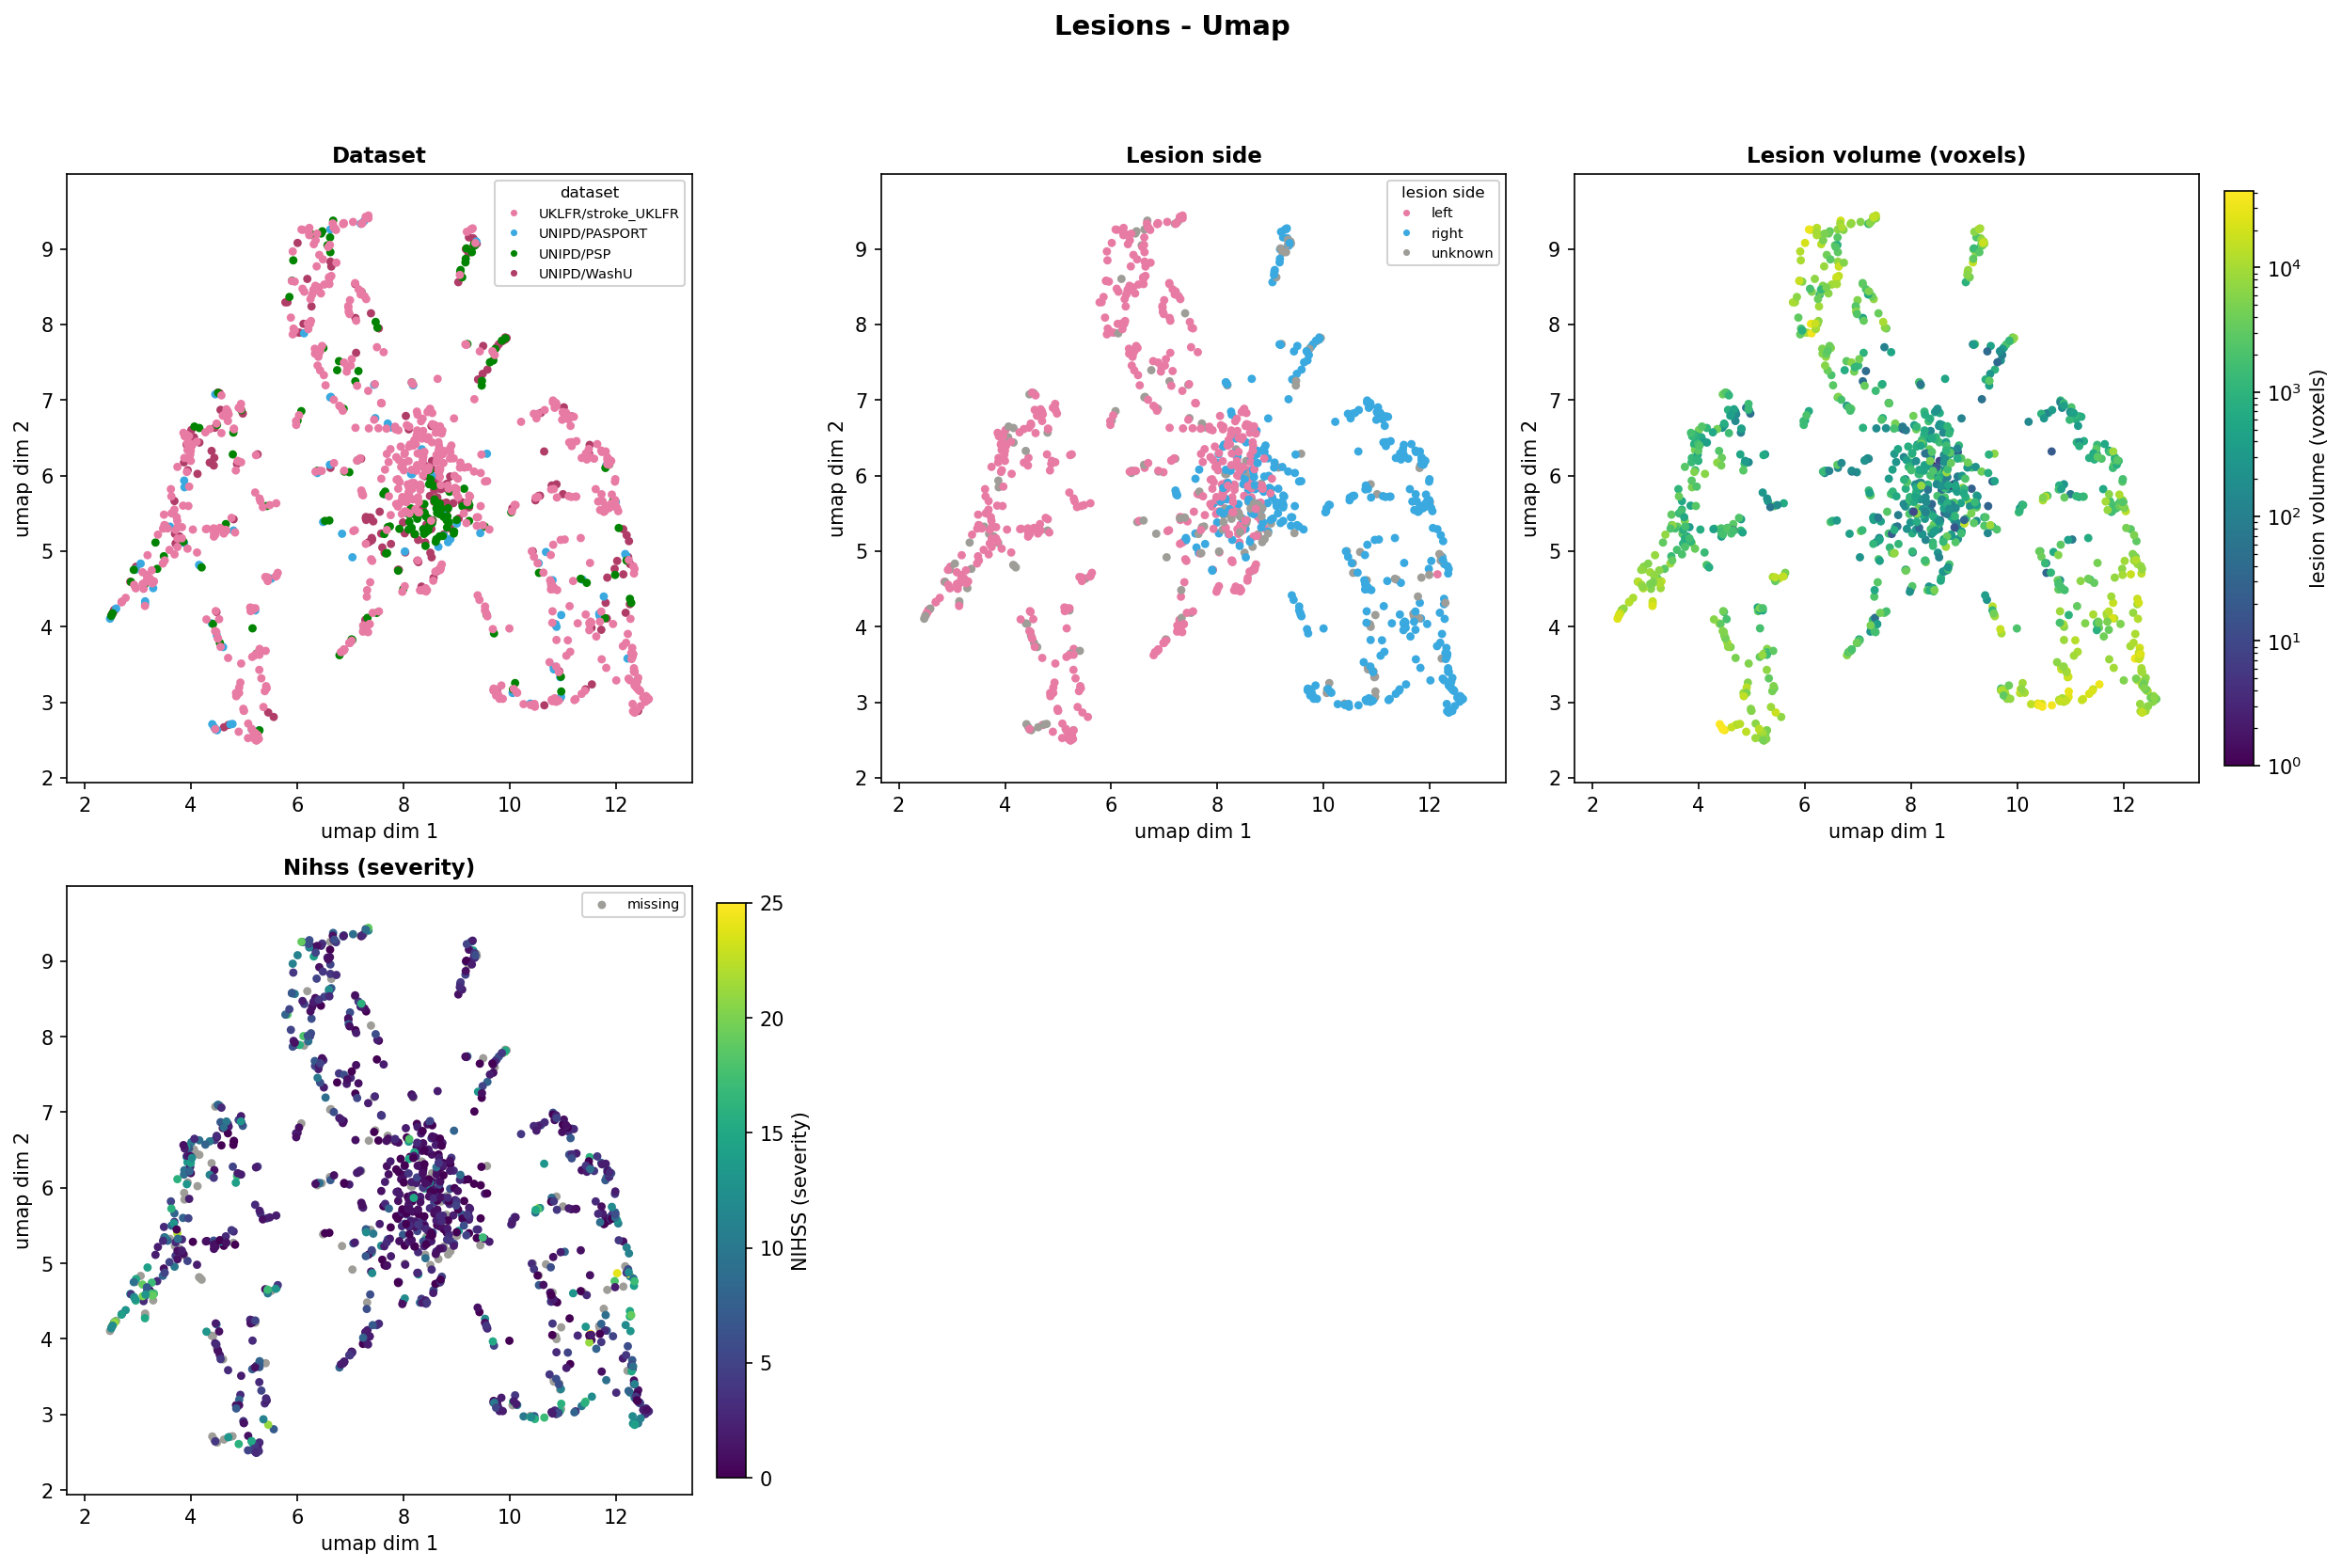

In [8]:
if 'embedding' in locals() and embedding.shape[1] >= 2:
    n_panels = len(color_by)
    ncols = min(3, n_panels)
    nrows = -(-n_panels // ncols)  # ceil
    panel_size = 5.5  # stessa dimensione per ogni box

    fig, axs = plt.subplots(nrows, ncols, figsize=(panel_size * ncols, panel_size * nrows), constrained_layout=True)
    axs = np.atleast_1d(axs).flatten()

    for ax, name in zip(axs, color_by):
        plot_embedding_panel(ax, embedding[:, :2], name, metadata, _panel_title(name), f"{reduction_method} dim 1", f"{reduction_method} dim 2")
    for ax in axs[n_panels:]:
        ax.axis("off")

    fig.suptitle(compose_embedding_plot_title(results_dir_rel, reduction_method), fontsize=14, fontweight="bold")
    # Riserva esplicitamente lo spazio sopra i pannelli per il suptitle (constrained_layout da
    # solo lo stima ma con poco margine - qui il titolo finiva a ridosso della riga di pannelli).
    fig.get_layout_engine().set(rect=(0, 0, 1, 0.94))

    # Salva su file e mostra da li' con Image (stesso trucco di show_embedding_single) -
    # display(fig) dipende dal backend matplotlib attivo in quel momento nel kernel (fragile,
    # nilearn lo puo' resettare - vedi cella import), un PNG caricato con Image no.
    with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as tmp:
        grid_path = Path(tmp.name)
    fig.savefig(grid_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=str(grid_path)))
else:
    print("Dati non caricati o embedding con meno di 2 dimensioni.")


## 3. Visualizzazione interattiva (Plotly) — 2D e 3D

In [9]:
def show_embedding_plotly(coords, mode_name, metadata, title, xlabel, ylabel, zlabel=None):
    """Plot Plotly 'unico' (una colorazione scelta a monte, nessun dropdown) - stessa
    palette/logica di COLOR_MODES (mai il tema/i colori di default di plotly express),
    sfondo bianco senza griglia, assi sottili."""
    is_3d = zlabel is not None
    scatter_cls = go.Scatter3d if is_3d else go.Scatter
    # In 3D, opacity<1 fa "impastare" per alpha-blending i punti vicini/sovrapposti in un'unica
    # macchia sfumata - il problema di leggibilita' segnalato non era (solo) l'aspect ratio gia'
    # corretto sotto, ma proprio questo. opacity=1 + un sottile bordo bianco (si vede come un
    # alone di separazione anche tra punti adiacenti, dato che lo sfondo template e' bianco) da'
    # ad ogni punto un contorno netto invece di fondersi con i vicini. In 2D l'affollamento e'
    # molto minore (nessun effetto di proiezione/rotazione), quindi resta lo stile precedente.
    marker_kwargs = dict(
        size=6,
        opacity=1.0 if is_3d else 0.85,
        line=dict(width=0.6, color="white") if is_3d else dict(width=0),
    )
    subject_ids = metadata["subject_id"].to_numpy() if "subject_id" in metadata.columns else None

    def _trace_kwargs(mask=None):
        idx = np.where(mask)[0] if mask is not None else np.arange(coords.shape[0])
        kw = dict(x=coords[idx, 0], y=coords[idx, 1])
        if is_3d:
            kw["z"] = coords[idx, 2]
        if subject_ids is not None:
            kw["text"] = subject_ids[idx]
            kw["hoverinfo"] = "text"
        return kw

    fig = go.Figure()

    if mode_name == "neutro":
        fig.add_trace(scatter_cls(**_trace_kwargs(), mode="markers", marker=dict(color="#3aa9e0", **marker_kwargs)))
    else:
        mode = COLOR_MODES[mode_name]
        values = metadata[_PERSISTED_COLUMN_BY_MODE[mode_name]].to_numpy()

        if mode.kind == "categorical":
            unique_categories = sorted(pd.unique(values).tolist())
            palette = _palette_for(unique_categories)
            for cat in unique_categories:
                fig.add_trace(scatter_cls(**_trace_kwargs(values == cat), mode="markers", name=str(cat),
                                           marker=dict(color=palette[cat], **marker_kwargs)))
        else:
            values = np.asarray(values, dtype=float)
            is_missing = np.isnan(values)
            color_values = values
            colorbar_title = mode.label
            if mode.log_scale:
                color_values = np.log10(values)
                colorbar_title = f"{mode.label} (log10)"

            if is_missing.any():
                fig.add_trace(scatter_cls(**_trace_kwargs(is_missing), mode="markers", name="missing",
                                           marker=dict(color=_NOISE_COLOR, **marker_kwargs)))
            fig.add_trace(scatter_cls(**_trace_kwargs(~is_missing), mode="markers", name=mode.label,
                                       marker=dict(color=color_values[~is_missing], colorscale="Viridis",
                                                   colorbar=dict(title=colorbar_title), **marker_kwargs)))

    axis_style = dict(showgrid=False, zeroline=False, showline=True, linewidth=1, linecolor="black")
    layout_kwargs = dict(
        # x=0.02/xanchor="left" invece del default centrato - un titolo lungo (es. con la chiave
        # combo del tuning) resta leggibile su una riga invece di sovrapporsi al centro del plot.
        title=dict(text=title, font=dict(size=15), x=0.02, xanchor="left"),
        template="simple_white",
        # Width fissa (non responsive): il tentativo precedente (nessuna width, responsive=True)
        # riempiva tutta la larghezza del pannello di output, risultando piu' largo di quanto
        # voluto - 680px e' volutamente piu' stretto della vecchia width fissa (750, che invece
        # veniva tagliata a bordo canvas in quel contenitore) ma comunque leggibile.
        width=680,
        height=650 if is_3d else 550,
        margin=dict(l=10, r=10, t=70, b=10),
    )
    if is_3d:
        thin_axis = dict(showbackground=False, showgrid=False, zeroline=True, linewidth=1, showline=True)
        layout_kwargs["scene"] = dict(
            xaxis=dict(title=xlabel, **thin_axis),
            yaxis=dict(title=ylabel, **thin_axis),
            zaxis=dict(title=zlabel, **thin_axis),
            # "data": le 3 scale assi rispettano la spanning reale dei punti invece di essere
            # tirate ognuna al proprio cubo (default "auto") - quella distorsione e' il motivo
            # principale per cui la nuvola sembrava un blob compatto senza struttura leggibile.
            aspectmode="data",
        )
    else:
        layout_kwargs["xaxis"] = dict(title=xlabel, **axis_style)
        layout_kwargs["yaxis"] = dict(title=ylabel, **axis_style)

    fig.update_layout(**layout_kwargs)
    fig.show()


### 3.1 Plot unico 2D, colorazione a scelta

In [10]:
# "neutro" oppure uno dei nomi di COLOR_MODES: "dataset", "side", "volume", "nihss"
plotly_color_by_2d = "neutro"


In [11]:
if 'embedding' in locals() and embedding.shape[1] >= 2:
    show_embedding_plotly(
        embedding[:, :2], plotly_color_by_2d, metadata,
        compose_embedding_plot_title(results_dir_rel, reduction_method, _color_label(plotly_color_by_2d)),
        f"{reduction_method} dim 1", f"{reduction_method} dim 2",
    )
else:
    print("Dati non caricati o embedding con meno di 2 dimensioni.")


### 3.2 Plot unico 3D, colorazione a scelta

In [12]:
# Nessun run di produzione a 3 componenti esiste ancora - carichiamo da un run di tuning
# (embeddings.npz, save_tuning_embeddings=true) che ha gia' le combinazioni a n_components=3.
tuning_dir_3d = root_path / "results/lesion/dim_reduction/tuning/umap/13-08_s1.1-vol"
embeddings_npz = np.load(tuning_dir_3d / "embeddings.npz")

# Scegli qui la combinazione esatta (stessa chiave leggibile di tuning_results.csv - vedi
# src/pipeline/dim_reduction.py::_combo_key, ordine metric,n_components,n_neighbors,min_dist)
combo_key_3d = "metric=dice,n_components=3,n_neighbors=15,min_dist=0.1"

if combo_key_3d not in embeddings_npz:
    raise KeyError(
        f"{combo_key_3d!r} non tra le combinazioni salvate - alcune disponibili: {list(embeddings_npz.keys())[:8]}"
    )
embedding_3d = embeddings_npz[combo_key_3d]
metadata_3d = pd.read_csv(tuning_dir_3d / "metadata.csv")
# Stessa convenzione di results_dir/reduction_method sopra: il nome della cartella subito sopra
# la sessione di tuning e' il metodo di riduzione - letto dal path, mai hardcoded. Stesso motivo
# per tuning_dir_3d_rel: compose_embedding_plot_title si aspetta un path relativo a "results/...".
reduction_method_3d = tuning_dir_3d.parent.name
tuning_dir_3d_rel = tuning_dir_3d.relative_to(root_path)
print(f"Embedding 3D caricato: shape {embedding_3d.shape}")
print(f"Combinazione: {combo_key_3d}")


Embedding 3D caricato: shape (1150, 3)
Combinazione: metric=dice,n_components=3,n_neighbors=15,min_dist=0.1


In [13]:
# "neutro" oppure uno dei nomi di COLOR_MODES: "dataset", "side", "volume", "nihss"
plotly_color_by_3d = "neutro"


In [14]:
if 'embedding_3d' in locals() and embedding_3d.shape[1] >= 3:
    show_embedding_plotly(
        embedding_3d[:, :3], plotly_color_by_3d, metadata_3d,
        compose_embedding_plot_title(tuning_dir_3d_rel, reduction_method_3d, _color_label(plotly_color_by_3d)),
        f"{reduction_method_3d} dim 1", f"{reduction_method_3d} dim 2", zlabel=f"{reduction_method_3d} dim 3",
    )
else:
    print("Embedding 3D non caricato o con meno di 3 componenti.")


## 4. Visualizzatore 3D Interattivo di Anatomia Lesionale (Nilearn)

Selezionando il codice di un soggetto (es. `sub-STUNIPD0001`), cerchiamo il suo file NIfTI originale e lo visualizziamo in 3D overlayato su un cervello standard MNI152.

Trovata lesione per sub-STUNIPD0001 in: /Users/emmatosato/Local Projects/Local PhD Projects/NEMESIS_fs/data/clinical_connectome/derivatives/UNIPD/WashU/manual_masks/sub-STUNIPD0001/anat/sub-STUNIPD0001_space-MNI152NLin6Asym_label-lesion_mask.nii.gz
Caricamento del visualizzatore 3D interattivo (puoi ruotare, zoomare e selezionare i piani di taglio)...


/opt/anaconda3/envs/nemesis/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:867: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/var/folders/8b/7njxgsdn39gd2dfjjnynjq140000gn/T/ipykernel_63140/4096581202.py:24: UserWarning: Resampling binary images with continuous or linear interpolation. This might lead to unexpected results. You might consider using nearest interpolation instead.
  view = plotting.view_img(



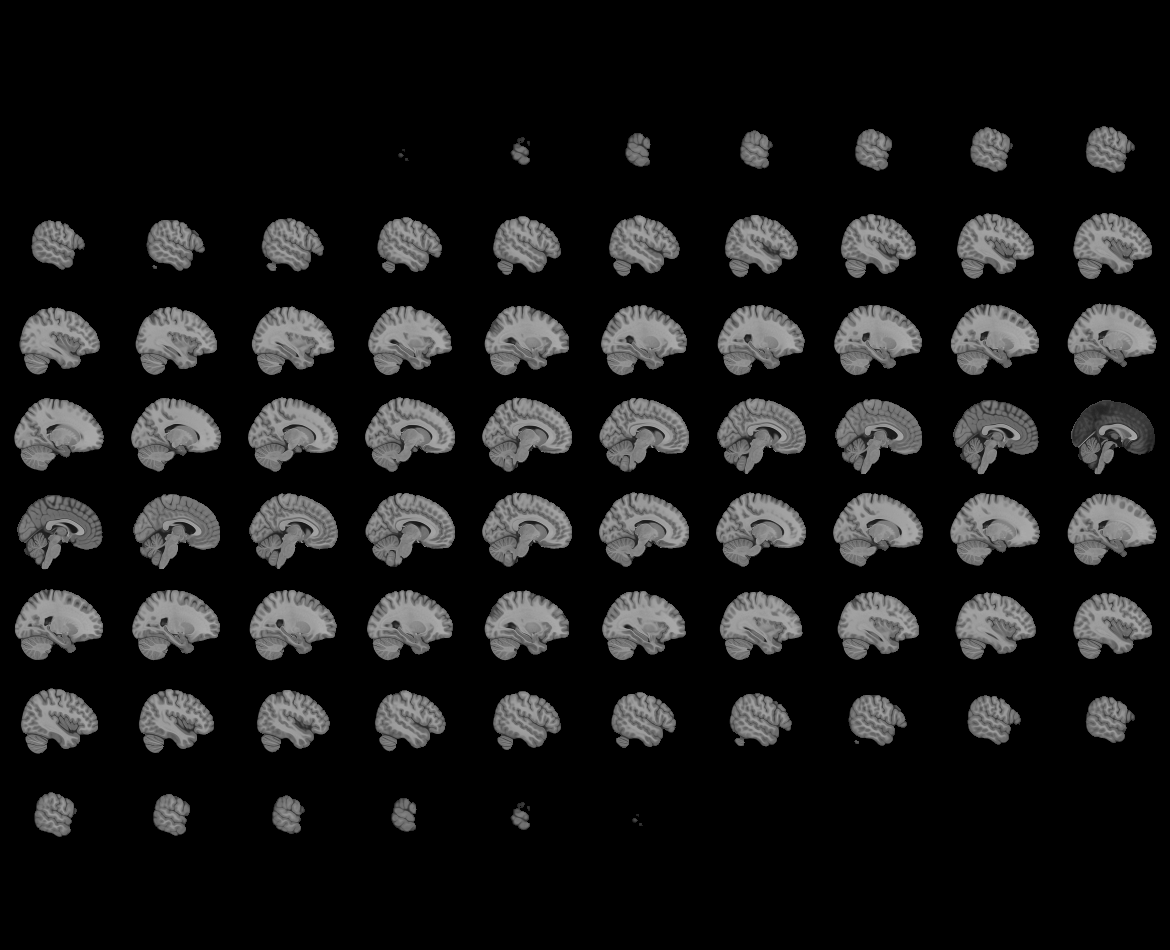
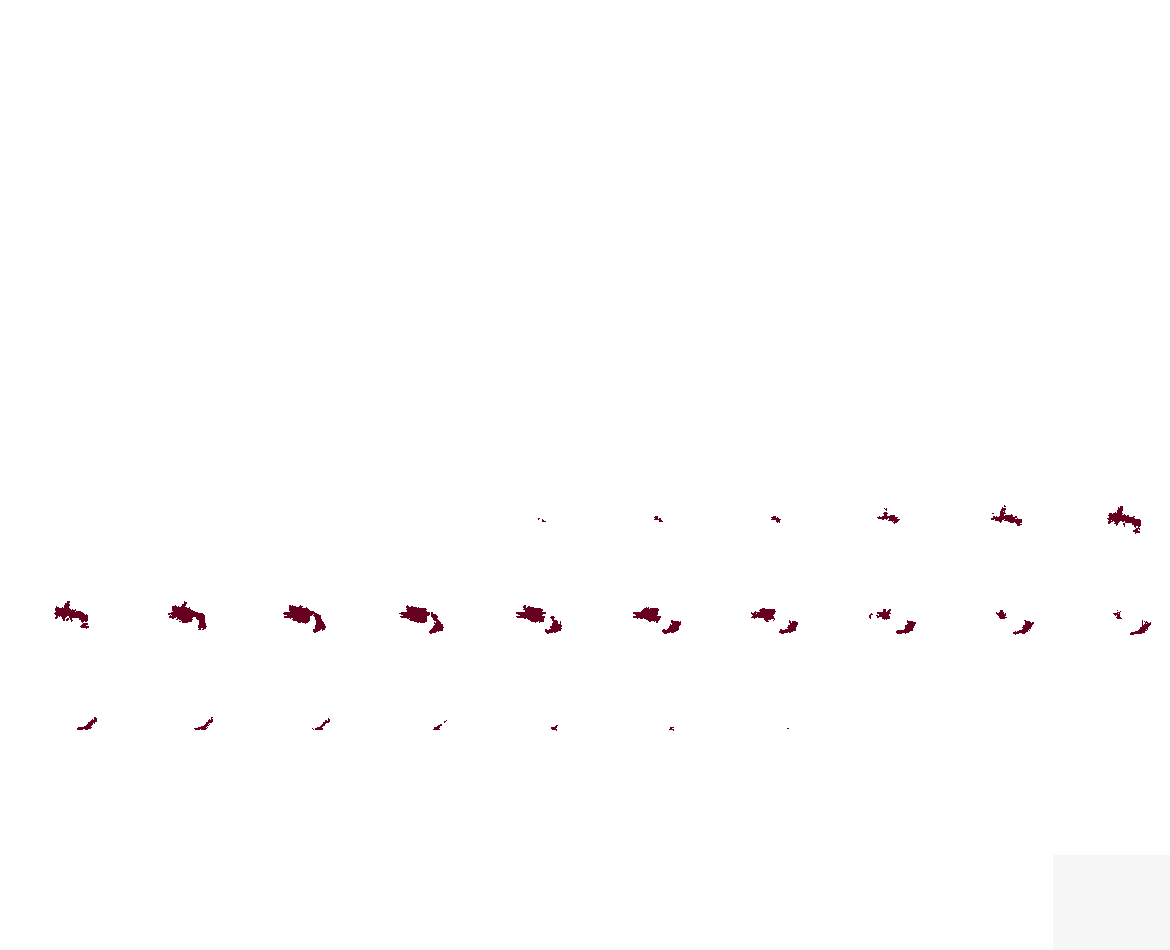

In [15]:
if 'metadata' in locals():
    # Inserisci il subject_id da ispezionare
    selected_subject = "sub-STUNIPD0001" 

    # Percorso principale dei dati clinici BIDS
    data_root = root_path / "data/clinical_connectome/derivatives"  # path assoluto via root_path (cella 1) - il precedente "../data/..." relativo risolveva al posto sbagliato a seconda di come il kernel Jupyter viene lanciato

    # Troviamo il dataset del soggetto cercato
    if selected_subject in metadata["subject_id"].values:
        subject_row = metadata[metadata["subject_id"] == selected_subject].iloc[0]
        dataset_name = subject_row.get("dataset", subject_row.get("dataset_x", None))
        
        if dataset_name:
            # Costruiamo il percorso del manual mask
            lesion_dir = data_root / dataset_name / "manual_masks" / selected_subject / "anat"
            lesion_files = list(lesion_dir.glob("*_label-lesion_mask.nii.gz"))
            
            if lesion_files:
                lesion_path = lesion_files[0]
                print(f"Trovata lesione per {selected_subject} in: {lesion_path}")
                print("Caricamento del visualizzatore 3D interattivo (puoi ruotare, zoomare e selezionare i piani di taglio)...")
                
                # Creiamo il visualizzatore 3D di Nilearn
                view = plotting.view_img(
                    str(lesion_path), 
                    threshold=0.5, 
                    bg_img="MNI152", 
                    title=f"Lesione: {selected_subject} ({dataset_name})"
                )
                # Mostra la view interattiva nel cell output
                display(view)
            else:
                print(f"Errore: Nessun file NIfTI lesion_mask trovato in {lesion_dir}")
        else:
            print(f"Errore: Dataset non trovato nei metadati per {selected_subject}")
    else:
        available_subjects = list(metadata["subject_id"].head(10))
        print(f"Soggetto {selected_subject} non presente in questa matrice.")
        print(f"Esempi di soggetti disponibili nella matrice corrente: {available_subjects}")
else:
    print("Dati non caricati.")

## 5. Soggetti Distanziati nello Spazio dell'Embedding e Lesione Reale

Questa sezione **non richiede alcun clustering** (a differenza della precedente versione di questa sezione, che assumeva un'assegnazione a cluster già fatta - quel tipo di analisi, overlap map *per cluster*, vive ora in `notebooks/post-results_analysis/embedding_to_anatomy_mapping.ipynb`, da riprendere una volta fatto clustering).

Qui invece: si scelgono pochi soggetti **ben distanziati tra loro** nello spazio dell'embedding già caricato in §1 (`embedding`/`reduction_method`/`metadata`), e per ciascuno si mostra la sua lesione reale in spazio anatomico MNI, con una linea che collega visivamente il punto al cervello corrispondente - un modo rapido per farsi un'idea qualitativa di cosa distingue regioni diverse dell'embedding, prima ancora di clusterizzare formalmente.

In [17]:
# Quanti soggetti-esempio mostrare, e seed per la selezione (farthest-point sampling qui sotto
# e' deterministico dato il seed - cambialo per pescare un altro set di soggetti "ben distanziati").
n_examples = 6
sample_seed = 0

# Layout retrieval corrente (stesso di config/pipelines/build_lesion_matrix.json) - non lo stesso
# per forza del run storico che ha prodotto "embedding" sopra: si risolve sempre dal layout di
# oggi, mai da un path storico potenzialmente non piu' esistente sul disco (vedi
# notebooks/post-results_analysis/embedding_to_anatomy_mapping.ipynb per il caso reale in cui
# questo ha fatto la differenza).
example_data_root = root_path / "data/clinical_connectome/derivatives"
example_lesion_glob = "manual_masks/*/anat/*_label-lesion_mask.nii.gz"


def farthest_point_sample(coords: np.ndarray, k: int, seed: int = 0) -> np.ndarray:
    """k indici ben distanziati tra loro (farthest-point sampling): parte da un
    punto casuale, poi ad ogni passo aggiunge il piu' lontano (euclideo, sulle
    coordinate dell'embedding) da tutti quelli gia' scelti - "a caso ma
    distanziato", non un campionamento uniforme puro che potrebbe pescare per
    caso due punti vicini."""
    n = coords.shape[0]
    if k > n:
        raise ValueError(f"n_examples={k} > numero di soggetti disponibili ({n})")
    rng = np.random.default_rng(seed)
    chosen = [int(rng.integers(n))]
    min_dist = np.linalg.norm(coords - coords[chosen[0]], axis=1)
    for _ in range(k - 1):
        next_idx = int(np.argmax(min_dist))
        chosen.append(next_idx)
        min_dist = np.minimum(min_dist, np.linalg.norm(coords - coords[next_idx], axis=1))
    return np.array(chosen)


def resolve_lesion_paths(subject_ids, dataset_by_subject, data_root, lesion_glob):
    """subject_id -> path del suo file di lesione, sotto il layout di retrieval
    corrente. Raggruppa per dataset (una sola discover_files_by_subject per
    dataset coinvolto, non una per soggetto). Solleva ValueError se un
    soggetto richiesto non si trova - mai una mappa costruita silenziosamente
    su meno soggetti di quanti dichiarati."""
    by_dataset = {}
    for subject_id in subject_ids:
        by_dataset.setdefault(dataset_by_subject[subject_id], []).append(subject_id)
    resolved, missing = {}, []
    for dataset, wanted in by_dataset.items():
        found, _ = discover_files_by_subject(data_root, dataset, lesion_glob, group_filter=None)
        for subject_id in wanted:
            if subject_id in found:
                resolved[subject_id] = found[subject_id]
            else:
                missing.append(subject_id)
    if missing:
        raise ValueError(f"soggetti non trovati sotto {data_root} (glob={lesion_glob!r}): {sorted(missing)}")
    return resolved


if 'embedding' in locals() and embedding.shape[1] >= 2:
    example_coords = embedding[:, :2]
    example_indices = farthest_point_sample(example_coords, n_examples, seed=sample_seed)
    example_subjects = metadata.iloc[example_indices].reset_index(drop=True)
    example_paths = resolve_lesion_paths(
        example_subjects["subject_id"].tolist(),
        dict(zip(metadata["subject_id"], metadata["dataset"])),
        example_data_root, example_lesion_glob,
    )
    display(example_subjects[["subject_id", "dataset"]].assign(
        **{f"{reduction_method}_dim1": example_coords[example_indices, 0],
           f"{reduction_method}_dim2": example_coords[example_indices, 1]}
    ))
else:
    print("Dati non caricati o embedding con meno di 2 dimensioni.")

,subject_id,dataset,umap_dim1,umap_dim2
0,sub-STUKLFR0559,UKLFR/stroke_UKLFR,8.670222,6.397180
1,sub-STUNIPD0548,UNIPD/PASPORT,2.479201,4.105690
2,sub-STUKLFR0320,UKLFR/stroke_UKLFR,12.620881,3.042579
3,sub-STUKLFR0632,UKLFR/stroke_UKLFR,6.082372,9.256104
4,sub-STUNIPD0373,UNIPD/PSP,6.798283,3.622550
5,sub-STUKLFR0625,UKLFR/stroke_UKLFR,11.912769,6.192901


### 5.1 Cervello + punto nell'embedding, collegati

Ogni riquadro è un *glass brain* (proiezione assiale, sfondo nero) della lesione reale del soggetto, con una linea grigia che lo collega al suo punto (numerato, in rosso) nello spazio dell'embedding al centro.

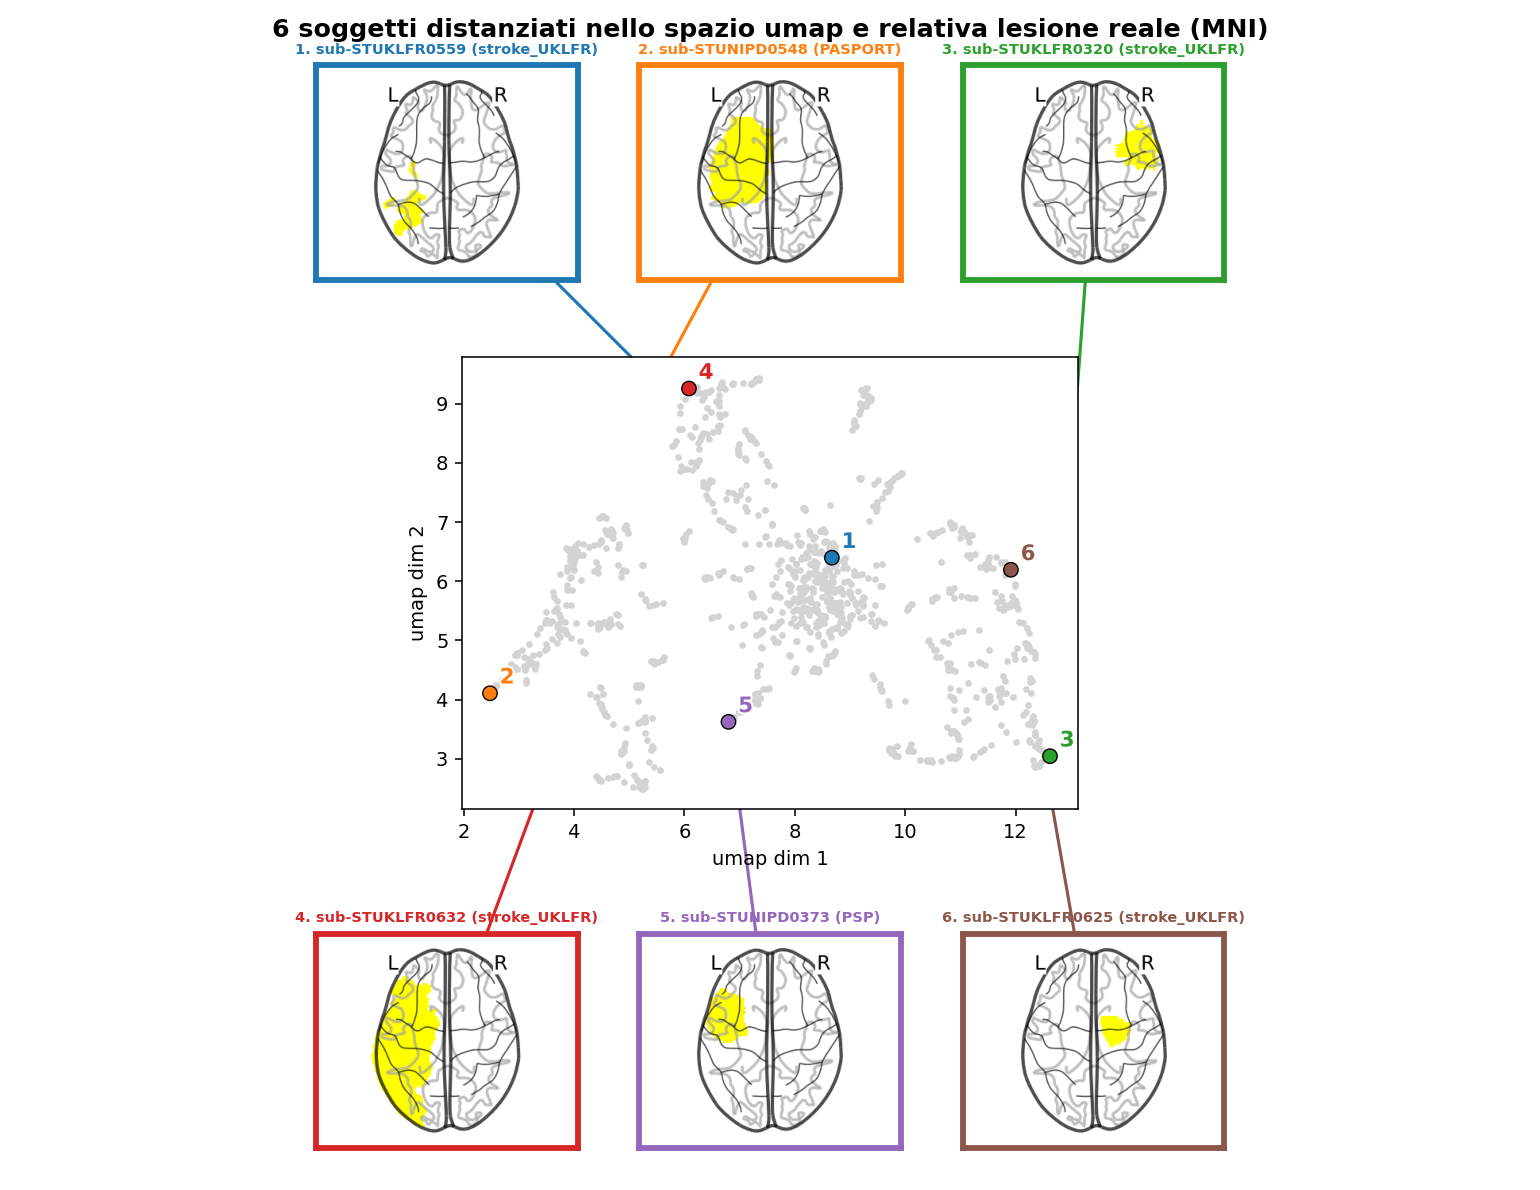

In [18]:
def _render_glass_brain_thumbnail(lesion_path):
    """Un piccolo PNG glass-brain (proiezione assiale, sfondo bianco, lesione
    in rosso/giallo) per un soggetto. threshold=0.5 e' essenziale: senza,
    ogni voxel=0 (la quasi totalita' del volume) viene comunque colorato
    dalla colormap, coprendo l'intero cervello invece di lasciarlo bianco."""
    thumb_fig = plt.figure(figsize=(2.0, 1.6))
    plotting.plot_glass_brain(
        str(lesion_path), display_mode="z", colorbar=False, cmap="autumn",
        black_bg=False, threshold=0.5, figure=thumb_fig,
    )
    with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as tmp:
        thumb_path = Path(tmp.name)
    thumb_fig.savefig(thumb_path, dpi=150, bbox_inches="tight", facecolor="white")
    plt.close(thumb_fig)
    return thumb_path


def plot_embedding_examples_with_lesions(coords, indices, subjects, paths, reduction_method):
    k = len(indices)
    thumbnails = [_render_glass_brain_thumbnail(paths[sid]) for sid in subjects["subject_id"]]
    # Un colore diverso per ogni soggetto-esempio, riusato identico su puntino, numero, linea
    # di collegamento e bordo del riquadro - cosi' il legame punto<->cervello e' inequivocabile a
    # colpo d'occhio, non solo tramite una linea sottile grigia. _CATEGORICAL_PALETTE (5 colori,
    # pensata per poche categorie come dataset/side) non basta a garantire k colori distinti per
    # un n_examples arbitrario - tab10 (10 colori) copre senza ripetizioni il range ragionevole per
    # questo tipo di selezione qualitativa; oltre i 10 esempi tab20 (20) subentra allo stesso modo.
    _tab_palette = plt.cm.tab10.colors if k <= 10 else plt.cm.tab20.colors
    example_colors = [_tab_palette[n % len(_tab_palette)] for n in range(k)]

    fig = plt.figure(figsize=(11, 8.5), facecolor="white")
    ax_main = fig.add_axes([0.30, 0.32, 0.40, 0.38])
    ax_main.scatter(coords[:, 0], coords[:, 1], s=6, color="lightgray", zorder=1)
    ax_main.scatter(coords[indices, 0], coords[indices, 1], s=55, color=example_colors, edgecolor="black", linewidth=0.7, zorder=3)
    for n, i in enumerate(indices):
        ax_main.annotate(
            str(n + 1), (coords[i, 0], coords[i, 1]), textcoords="offset points", xytext=(5, 5),
            fontsize=11, fontweight="bold", color=example_colors[n],
            path_effects=[pe.withStroke(linewidth=2, foreground="white")],  # leggibile su sfondo chiaro/scuro misto
        )
    ax_main.set_xlabel(f"{reduction_method} dim 1")
    ax_main.set_ylabel(f"{reduction_method} dim 2")

    n_top = -(-k // 2)
    n_bottom = k - n_top
    top_xs = np.linspace(0.08, 0.92, n_top + 2)[1:-1]
    bottom_xs = np.linspace(0.08, 0.92, n_bottom + 2)[1:-1]
    inset_w, inset_h = 0.17, 0.19
    positions = [(x, 0.76) for x in top_xs] + [(x, 0.03) for x in bottom_xs]

    for n, ((cx, cy), thumb_path) in enumerate(zip(positions, thumbnails)):
        color = example_colors[n]
        ax_inset = fig.add_axes([cx - inset_w / 2, cy, inset_w, inset_h])
        ax_inset.imshow(plt.imread(thumb_path))
        ax_inset.set_xticks([])
        ax_inset.set_yticks([])
        for spine in ax_inset.spines.values():
            spine.set_visible(True)
            spine.set_color(color)
            spine.set_linewidth(3)
        row = subjects.iloc[n]
        ax_inset.set_title(f"{n + 1}. {row['subject_id']} ({row['dataset'].split('/')[-1]})", fontsize=7.5, color=color, fontweight="bold")
        px, py = coords[indices[n], 0], coords[indices[n], 1]
        fig.add_artist(ConnectionPatch(
            xyA=(px, py), coordsA=ax_main.transData, xyB=(0.5, 0.5), coordsB=ax_inset.transAxes,
            color=color, linewidth=1.6, zorder=0,
        ))

    fig.suptitle(f"{k} soggetti distanziati nello spazio {reduction_method} e relativa lesione reale (MNI)", fontsize=13, fontweight="bold", y=0.985)
    return fig


if 'example_indices' in locals():
    fig = plot_embedding_examples_with_lesions(example_coords, example_indices, example_subjects, example_paths, reduction_method)
    # Salva su file e mostra da li' con Image (stesso trucco di show_embedding_single/2.2 sopra) -
    # plt.show()/display(fig) qui sotto dipendono dal backend matplotlib attivo in quel momento nel
    # kernel, e plot_glass_brain (chiamato piu' volte sopra per i thumbnail) lo puo' aver resettato
    # ad Agg (non interattivo) nel frattempo - un PNG caricato con Image no.
    with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as tmp:
        composite_path = Path(tmp.name)
    fig.savefig(composite_path, dpi=140, bbox_inches=None, facecolor="white")
    plt.close(fig)
    display(Image(filename=str(composite_path)))
else:
    print("Nessun soggetto-esempio selezionato (vedi cella sopra).")